## Overview (23/01/2026)
Here we apply the DRT functionality to degrading curves over time from a (full MAPI device?)

In [1]:
# import statements
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../../../..')
    import pySIMsalabim as sim
from pySIMsalabim.experiments import impls
from pySIMsalabim.aux_funcs import time_domain_DRT as drt

In [8]:
# Read in data 
directory_path = "/home/josh-edmundson/Documents/Projects/Applying DRT Fitting to Device Degridation Data/RUG/JVs/"

# 'During Experiment' (DE) data sets at temps of 65C and 85C
data_DE_85C_MPPT = pd.read_csv(directory_path + 'JV-85C (during experiment)/MPPT_metrics.txt', sep=r"\s+", encoding='unicode_escape')

In [10]:
# Check data has been read in correctly
data_DE_85C_MPPT.head()

,Time[h],Voc[V],|Jsc|[mA/cm²],PCE[%],FillFactor,Vmp[V],Jmp[mA/cm²],MaxPower[mW/cm²]
0,0.000,0.9504,25.54,17.9760,0.7406,0.80,22.47,17.9760
1,2.001,0.9334,25.14,18.1506,0.7735,0.78,23.27,18.1506
2,4.001,0.9251,24.99,18.0336,0.7801,0.78,23.12,18.0336
3,6.002,0.9229,24.86,17.8932,0.7799,0.78,22.94,17.8932
4,8.002,0.9209,24.79,17.7918,0.7794,0.78,22.81,17.7918


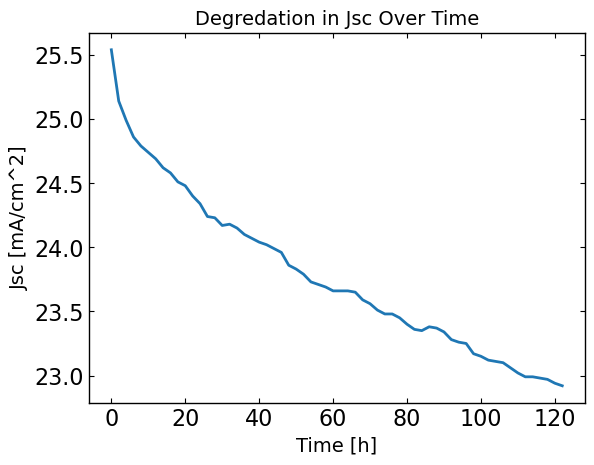

In [13]:
plt.plot(data_DE_85C_MPPT['Time[h]'], data_DE_85C_MPPT['|Jsc|[mA/cm²]'])
plt.xlabel("Time [h]")
plt.ylabel("Jsc [mA/cm^2]")
plt.title("Degredation in Jsc Over Time")
plt.show()

In [119]:
# Establish tau values
time = np.array(data_DE_85C_MPPT['Time[h]'])
current = np.array(data_DE_85C_MPPT['|Jsc|[mA/cm²]'])
current_scaled = current #(current - current.min())/(current.max() - current.min())

d_time = [time[i+1]-time[i] for i in range(len(time)-1)]
d_time_min = np.min(d_time)
T = time[-1] - time[0]

tau_min = d_time_min#/(np.pi)
tau_max = 1000*T#/(2*np.pi)

tau = np.linspace(tau_min, tau_max, len(time))

In [120]:
# Try applying DRT curve fit
checkerboard_iters=400
osqp_checkerboard = drt.osqp_checkerboard_fit(time,current_scaled, tau, checkerboard_iters=checkerboard_iters)

Text(0.5, 1.0, 'Checkerboard MSE at each iteration')

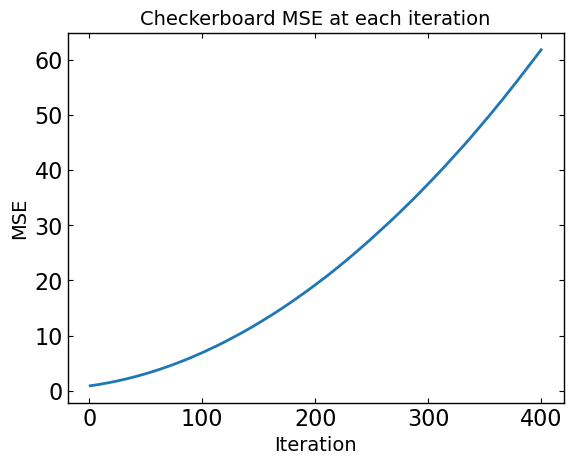

In [121]:
# Plot MSE 
MSE = [fit.cost for fit in osqp_checkerboard]
plt.plot(range(1, checkerboard_iters+1), MSE)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Checkerboard MSE at each iteration")

Text(0.5, 1.0, '$R^2$ error per iteration')

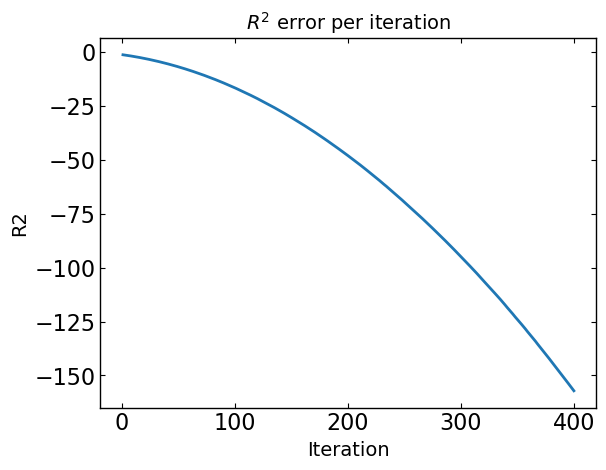

In [122]:
# Plot R^2 
def r2_error(data, model):
    SSres = np.sum((data - model)**2)
    SStot = np.sum((data - np.mean(data))**2)
    return 1 - SSres/SStot

R2 = [r2_error(current_scaled, fit.y) for fit in osqp_checkerboard]
plt.plot(range(1, checkerboard_iters+1), R2)
plt.xlabel("Iteration")
plt.ylabel("R2")
plt.title("$R^2$ error per iteration")

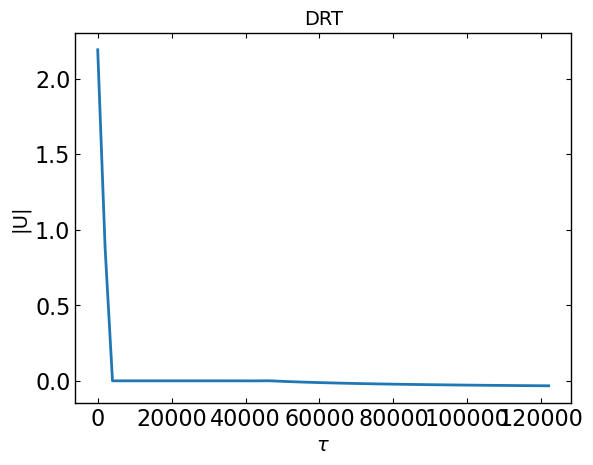

In [123]:
# Plot the distribution of relaxation times after 200 iterations
# Based on past experience, we'll select the fit where R^2 begins to level off ~iteration 200
fit_index = 1
plt.plot(tau, osqp_checkerboard[fit_index].U)
plt.xlabel('$\\tau$')
plt.ylabel("|U|")
plt.title("DRT")
plt.show()

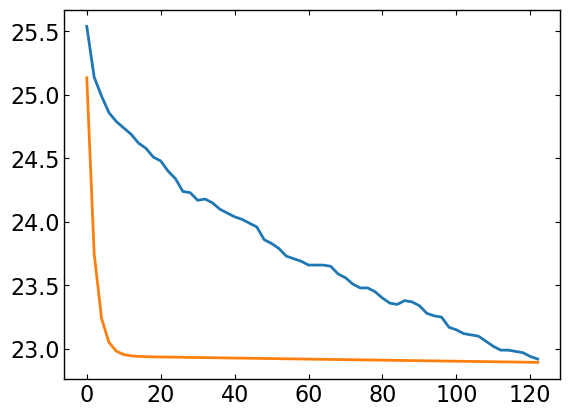

In [124]:
plt.plot(time, current_scaled)
plt.plot(time, osqp_checkerboard[fit_index].y)

In [136]:
# Try standard osqp linear fit 
osqp_linear_fit = drt.osqp_linear_fit(time, current_scaled, tau)

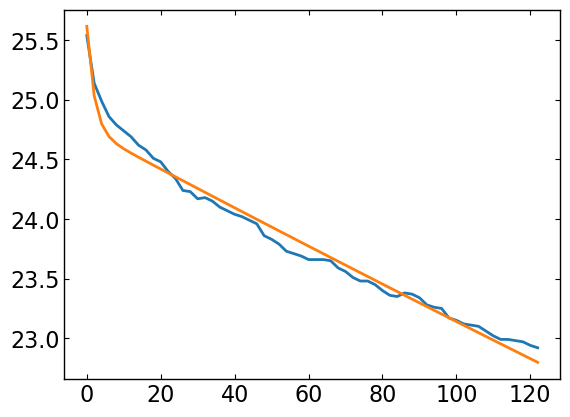

In [132]:
plt.plot(time, current)
plt.plot(time, osqp_linear_fit.y)

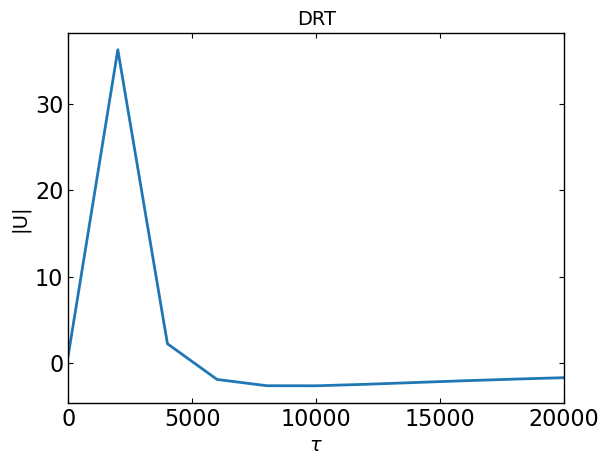

In [140]:
plt.plot(tau, osqp_linear_fit.U)
plt.xlabel('$\\tau$')
plt.xlim(0, 20000)
plt.ylabel("|U|")
plt.title("DRT")
plt.show()